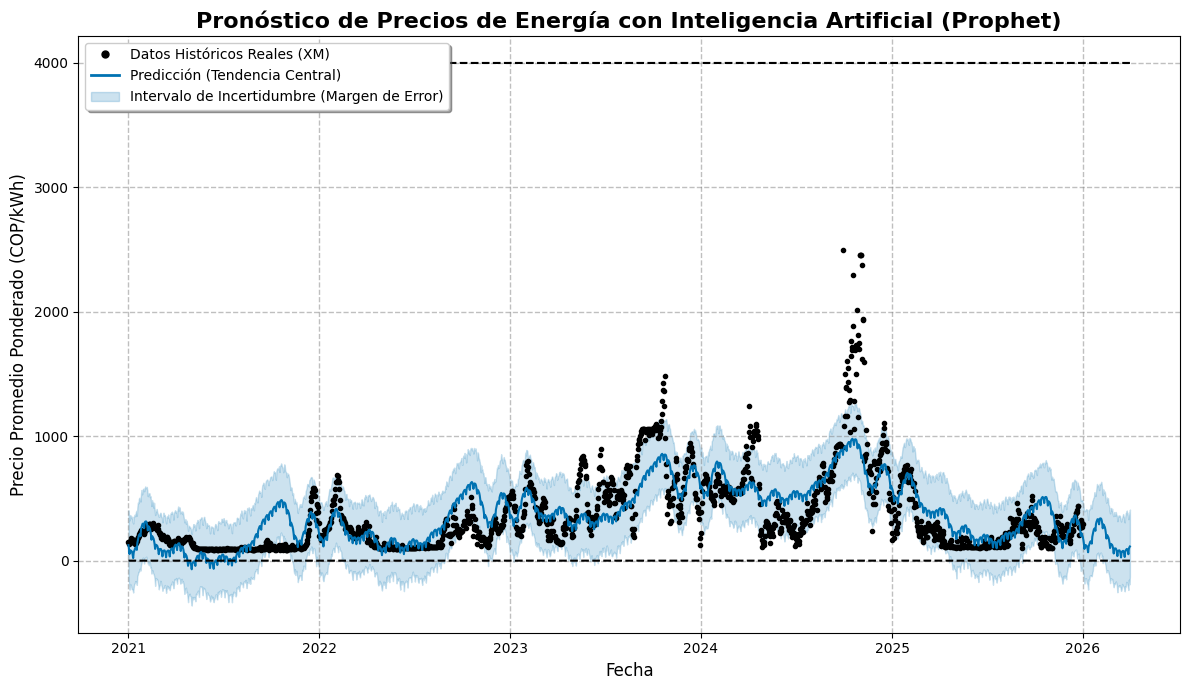

In [5]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

ruta_precio = '/content/data.csv'
df = pd.read_csv(ruta_precio, sep=None, engine='python', encoding='utf-8-sig')

df_ml = pd.DataFrame()
df_ml['ds'] = pd.to_datetime(df['Fecha'])
df_ml['y'] = df['PPP Bolsa diario']
df_ml = df_ml.sort_values('ds').dropna()

# Se establece un minimo y un maximo
df_ml['floor'] = 0
df_ml['cap'] = 4000 # el techo del modelo para este caso
modelo = Prophet(yearly_seasonality=True, daily_seasonality=False, growth='logistic')
modelo.fit(df_ml)

# Futuro a 90 dias
futuro = modelo.make_future_dataframe(periods=90)
futuro['floor'] = 0
futuro['cap'] = 4000
prediccion = modelo.predict(futuro)

# Grafico
fig = modelo.plot(prediccion, figsize=(12, 7))
ax = fig.gca()

# Leyenda
handle_datos = mlines.Line2D([], [], color='black', marker='o', linestyle='None',
                             markersize=5, label='Datos Históricos Reales (XM)')
handle_prediccion = mlines.Line2D([], [], color='#0072B2', linewidth=2,
                                  label='Predicción (Tendencia Central)')
handle_error = mpatches.Patch(color='#0072B2', alpha=0.2,
                              label='Intervalo de Incertidumbre (Margen de Error)')

ax.legend(handles=[handle_datos, handle_prediccion, handle_error],
          loc='upper left', fontsize=10, frameon=True, shadow=True)

# Decoración final
plt.title('Pronóstico de Precios de Energía con Inteligencia Artificial (Prophet)', fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Precio Promedio Ponderado (COP/kWh)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()